# 🇧🇴 Political Risk & Economic Sentiment Tracker (Bolivia)
## *High-Frequency Alternative Data Analysis*

**Objective:**
Transform daily unstructured news data into quantitative indicators of political exposure and institutional sentiment.

**Methodological Pipeline:**
1. **Data Ingestion:** Automated loading and concatenation of daily CSVs extracted by the 24h Web Scraper.
2. **Entity Exposure Tracking:** Cumulative mention tracking of key political figures to measure media exposure over time.
3. **Targeted Sentiment Analysis (Transformers):** Utilization of the `pysentimiento` (RoBERTuito) pipeline to calculate Positivity and Negativity indices for specific targets (e.g., Public Officials, Ministers) and evaluate overall media tone.

In [ ]:
import pandas as pd
import numpy as np
import os
import re
import unicodedata
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
# --- ANÁLISIS COMPLETO DE MÚLTIPLES ARCHIVOS CSV ---
# --- 1. CONFIGURACIÓN DEL RANGO DE FECHAS ---
# Aquí defines tu "lógica de tiempo". Puedes poner una fecha futura y el script simplemente saltará los archivos que aún no existen.
fecha_inicio = '2026-01-01'
fecha_fin = '2026-03-22'

# Generamos el rango automático (Maneja bisiestos, cambios de mes y año solo)
rango_fechas = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

# --- 2. CARGA DE DATOS ---
dataframes = []

print(f"Buscando archivos desde {fecha_inicio} hasta {fecha_fin}...")

for fecha in rango_fechas:
    # Convertimos la fecha del loop al formato del nombre del archivo (AAAA-MM-DD)
    fecha_str = fecha.strftime('%Y-%m-%d')
    nombre_archivo = f'noticias_{fecha_str}.csv'

    # Verificamos si existe antes de intentar leer (más limpio que try/except para FileNotFoundError)
    if os.path.exists(nombre_archivo):
        try:
            df_temp = pd.read_csv(nombre_archivo)
            dataframes.append(df_temp)
        except Exception as e:
            print(f"Error leyendo {nombre_archivo}: {e}")
    # Si no existe, simplemente pasa al siguiente día sin error

# Verificar si encontramos algo
if not dataframes:
    raise ValueError("No se encontraron archivos en el rango de fechas especificado.")

df_noticias = pd.concat(dataframes, axis=0, ignore_index=True)

# --- 3. LIMPIEZA Y PROCESAMIENTO ---

# Unificar fechas (Lógica vectorizada, más rápida)
df_noticias['fecha'] = pd.to_datetime(df_noticias['fecha'], errors='coerce').dt.date
# df_noticias['fecha_publicacion'] = pd.to_datetime(df_noticias['fecha_publicacion'], errors='coerce').dt.date
# df_noticias['fecha'] = df_noticias['fecha'].combine_first(df_noticias['fecha_publicacion'])
# df_noticias.drop(columns=['fecha_publicacion'], inplace=True)

# Limpieza de texto (Regex y Unicode)
def limpiar_texto(texto):
    if not isinstance(texto, str): return texto
    # Normalizar (quitar tildes)
    texto = ''.join(c for c in unicodedata.normalize('NFKD', texto) if unicodedata.category(c) != 'Mn')
    # Quitar caracteres especiales (manteniendo espacios y alfanuméricos)
    return pd.Series(texto).str.replace(r'[^a-zA-Z0-9\s]', '', regex=True).str.strip().str.title()[0]

df_noticias['seccion'] = df_noticias['seccion'].apply(limpiar_texto)

# --- 4. DICCIONARIO DE REEMPLAZOS (Lógica robusta de categorías) ---
# En lugar de múltiples líneas de .replace(), usamos un diccionario maestro.
diccionario_correcciones = {
    'Economia Y Empresa': 'Economia',
    'Energias Negocios': 'Economia',
    'Luis Arce': 'Politica',
    'Uno Decide': 'Politica',
    'Asi Decidimos': 'Politica',
    'Eduardo Del Castillo': 'Politica',
    'Social': 'Politica',
    'Politica Portada': 'Politica',
    'Nacionales': 'Nacional',
    'Nacional Portada': 'Nacional',
    'Pais': 'Nacional',
    'Bolivia': 'Nacional',
    'La Razon Plus': 'Nacional',
    'Voces': 'Opinion',
    'Columnistas': 'Opinion',
    'Opiniones': 'Opinion',
    'Animal Politico': 'Opinion',
    'Columna': 'Opinion',
    'Policial': 'Seguridad',
    'Portada Seguridad': 'Seguridad',
    'Triple Crimen En Abapo': 'Seguridad',
    'Santa Cruz': 'Local',
    'La Paz': 'Local',
    'Futbol': 'Deportes',
    'Futbol Boliviano': 'Deportes',
    'Internacional Marcas': 'Deportes',
    'La Verde': 'Deportes',
    'Event': 'Deportes',
    'A Todo Deporte': 'Deportes',
    'Polideportivo': 'Deportes',
    'Futbol Profesional Boliviano': 'Deportes',
    'Mundo': 'Internacional',
    'Internacionales': 'Internacional'
}

# Aplicar correcciones masivas
df_noticias['seccion'] = df_noticias['seccion'].replace(diccionario_correcciones)
df_noticias['sitio_noticias'] = df_noticias['sitio_noticias'].replace({'Éxito Noticias Bolivia': 'Éxito Noticias'})

# Resultado final
display(df_noticias)
print(f"Total de noticias cargadas: {len(df_noticias)}")

# # Generar la nube de palabras
# wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
# #Excluir palabras muy comunes
# wordcloud = WordCloud(width=800, height=400, background_color='white',
#                       stopwords={'e', 'es','de', 'la', 'y', 'el',
#                                  'que', 'en', 'a', 'los', 'del', 'se',
#                                  'las', 'por', 'un', 'para', 'con', 'no',
#                                  'una', 'su', 'al', 'lo', 'como', 'más',
#                                  'pero', 'sus', 'le', 'ya', 'o', 'este',
#                                  'sí', 'porque', 'esta', 'entre', 'cuando',
#                                  'muy', 'sin', 'sobre', 'también', 'me',
#                                  'hasta', 'hay', 'donde', 'quien', 'desde',
#                                  'todo', 'nos', 'durante', 'ante', 'contra',
#                                  'ha', 'fue', 'MIRA', 'AQUÍ', 'ese', 'otro',
#                                  'día', "año", "do", "Bolivia", "Ver", "tras",
#                                  "toda", "dijo", "según", "está", "lunes",
#                                  "martes", "son", "esto", "eso", "país",
#                                  "viernes", "dos", "años", "sábado", "miércoles",
#                                  "jueves", "domingo", "noviembre", "diciembre", "enero"}).generate(text)

# # Mostrar la nube de palabras
# plt.figure(figsize=(10, 5))
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis('off')
# plt.show()

Buscando archivos desde 2026-01-01 hasta 2026-03-22...


,sitio_noticias,fecha,seccion,titular,cuerpo,url
0,La Razón,2026-01-01,Opinion,Por sobre todas las cosas,Te odio. El odio parece que es la medida de cu...,https://larazon.bo/opinion/columnistas/2026/01...
1,La Razón,2026-01-01,Internacional,Rusia acusa a Ucrania de ataque con al menos 2...,Rusia acusó este jueves al ejército de Kiev de...,https://larazon.bo/mundo/2026/01/01/rusia-acus...
2,La Razón,2026-01-01,Internacional,Confirman ‘decenas’ de muertos por incendio en...,Las autoridades suizas han confirmado en la ma...,https://larazon.bo/mundo/2026/01/01/confirman-...
3,La Razón,2026-01-01,Internacional,Arabia Saudita ejecutó a más de 350 personas e...,Las autoridades de Arabia Saudita ejecutaron a...,https://larazon.bo/mundo/2026/01/01/arabia-sau...
4,La Razón,2026-01-01,Internacional,Ecuador declara estado de excepción en 9 provi...,"El presidente de Ecuador, Daniel Noboa , ha de...",https://larazon.bo/mundo/2026/01/01/ecuador-de...
...,...,...,...,...,...,...
26188,Visión 360,2026-03-22,Deportes,"Villamil: ""no me siento titular, el puesto hay...",Gabriel Villamil llegó esta tarde (15:00 hora ...,https://www.vision360.bo/noticias/2026/03/22/4...
26189,Visión 360,2026-03-22,Deportes,Fernández y Rocha son esperados el lunes por l...,Sports 360 / La Paz\n\nLos jugadores boliviano...,https://www.vision360.bo/noticias/2026/03/22/4...
26190,Visión 360,2026-03-22,Deportes,El entrenador Henk Ten Cate quiere regalarle a...,Sports 360 / La Paz\n\nEl técnico de la selecc...,https://www.vision360.bo/noticias/2026/03/22/4...
26191,Visión 360,2026-03-22,Deportes,"Iraquíes llegan a Monterrey y planean ir de ""e...",La plantilla completa de Irak tiene planificad...,https://www.vision360.bo/noticias/2026/03/22/4...


Total de noticias cargadas: 26193


In [ ]:
df_noticias['seccion'].value_counts()
# df_noticias[df_noticias['seccion'] == 'La Revista']

seccion
Internacional                             3013
Seguridad                                 2521
Nacional                                  2382
Economia                                  2290
Politica                                  2273
                                          ... 
El Pais Marcha Cob Decreto 5503              1
Cultura Literatura Edmundo Paz Soldan        1
Cultura Fallecidos 2025                      1
Musica Banda Corea Del Sur Bts Kpop          1
Autoridades Nuevas Llamado Rodrigo Paz       1
Name: count, Length: 2991, dtype: int64

In [ ]:
# Crear dataframe con secciones especificas
df_noticias_relevantes = df_noticias[df_noticias['seccion'].isin(['Politica', 'Nacional', 'Opinion', 'Seguridad',
                                                                  'Local', 'Economia', 'Internacional', 'Sociedad'])]
df_noticias_relevantes.to_csv('noticias_relevantes.csv', index=False)

In [ ]:
df_noticias_relevantes

,sitio_noticias,seccion,titular,cuerpo,url,fecha
0,La Razón,Economia,CNI alerta: Ley de diferimiento ‘atenta contra...,La Cámara Nacional de Industrias (CNI) se sumó...,https://larazon.bo/economia-y-empresa/2025/11/...,2025-11-07
1,La Razón,Economia,Exministro Parada busca ser remitido a juicio ...,El exministro de Economía José Luis Parada bus...,https://larazon.bo/economia-y-empresa/2025/11/...,2025-11-07
2,La Razón,Economia,"PGE 2026 prevé crecimiento de solo 0,9% y défi...",El Órgano Ejecutivo remitió a la Asamblea Legi...,https://larazon.bo/economia-y-empresa/2025/11/...,2025-11-07
3,La Razón,Economia,Asosur dice que surtidores están listos y agua...,La presidente de la Asociación departamental d...,https://larazon.bo/economia-y-empresa/2025/11/...,2025-11-07
4,La Razón,Economia,Banco Mundial y FLAR destacan avance de pagos ...,Estudios del Banco Mundial y del Fondo Latinoa...,https://larazon.bo/economia-y-empresa/2025/11/...,2025-11-07
...,...,...,...,...,...,...
32893,Radio FM Bolivia,Politica,Concentración de «Evo Pueblo» en Chimoré gener...,El movimiento político presentará a sus candid...,https://fmbolivia.com.bo/18/02/2026/concentrac...,2026-02-18
32894,Radio FM Bolivia,Nacional,TSE aparta a su presidente Gustavo Ávila de la...,La recusación aceptada por la Sala Plena impid...,https://fmbolivia.com.bo/18/02/2026/tse-aparta...,2026-02-18
32895,Radio FM Bolivia,Internacional,India acelera su apuesta por la inteligencia a...,La cumbre mundial en Nueva Delhi reúne a líder...,https://fmbolivia.com.bo/18/02/2026/india-acel...,2026-02-18
32896,Radio FM Bolivia,Politica,Seguidores de Evo se movilizan y advierten con...,El bloque “evista” prepara una concentración e...,https://fmbolivia.com.bo/18/02/2026/seguidores...,2026-02-18


In [ ]:
# Localizar URLs de las noticias referentes a un tema específico
tema = "litio"
df_tema = df_noticias[df_noticias['titular'].str.contains(tema, case=False, na=False)]
display(df_tema)

,sitio_noticias,seccion,titular,cuerpo,url,fecha
8,La Razón,Economia,El nuevo gobierno apunta a reescribir las regl...,"El presidente electo Rodrigo Paz, que asumirá ...",https://larazon.bo/economia-y-empresa/2025/11/...,2025-11-07
574,La Razón,Energias Negocios,Brasil se acerca a Australia en la carrera por...,La minera australiana Pilbara Minerals advirti...,https://larazon.bo/energias-negocios/2025/11/0...,2025-11-09
673,Éxito Noticias,Nacional,Lara en Potosí: “El litio no va a ser utilizad...,"- El vicepresidente del Estado, Edmand Lara, p...",https://exitonoticias.com.bo/lara-en-potosi-el...,2025-11-10
698,Opinión,Potosi,"Lara, sobre el litio: ‘Ahora Potosí toma las d...",En un discurso por la gesta libertaria de Poto...,https://www.opinion.com.bo/articulo/pais/lara-...,2025-11-10
715,Unitel,Economia,Ministro alemán: “Existe un consorcio australi...,"Johann David Wadephul, ministro federal de Rel...",https://unitel.bo/noticias/economia/ministro-a...,2025-11-10
739,Unitel,Politica,Lara en la efeméride potosina: “El litio no va...,"El vicepresidente de Bolivia, Edmand Lara, lle...",https://unitel.bo/noticias/politica/lara-en-la...,2025-11-10
931,La Razón,Economia,Expertos: Vaca Muerta es ‘llave de paso’ hacia...,Durante el conversatorio Escenarios y Oportuni...,https://larazon.bo/economia-y-empresa/2025/11/...,2025-11-12
2463,La Razón,Economia,Potosí impulsa propuesta económica y ambiental...,La exejecutiva de la Federación Regional Única...,https://larazon.bo/economia-y-empresa/2025/11/...,2025-11-17
2472,La Razón,Economia,Precio del litio en China sube 9% y toca su ni...,El mercado del litio volvió a dispararse este ...,https://larazon.bo/economia-y-empresa/2025/11/...,2025-11-17
2847,La Razón,Economia,Paz dice que ingresos del litio deben impulsar...,En el aniversario 183 del departamento de Beni...,https://larazon.bo/economia-y-empresa/2025/11/...,2025-11-18


<Axes: title={'center': 'Distribución de Sentimientos en Titulares de Economía'}, xlabel='sentimiento'>

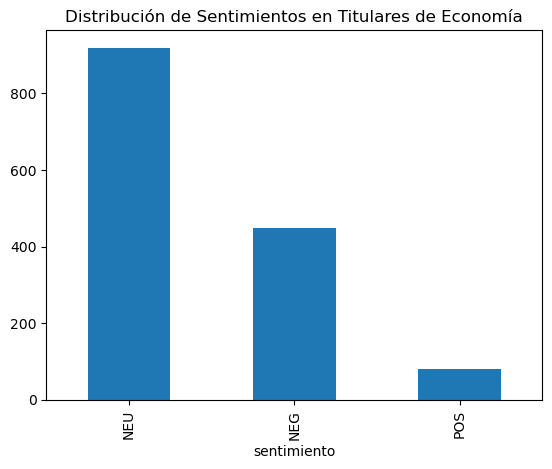

In [ ]:
# Extraer noticias de sección 'Economía' y realizar análisis de sentimiento de la columna 'titular' con pysentimiento
from pysentimiento import create_analyzer
analyzer = create_analyzer(task="sentiment", lang="es")
df_economia = df_noticias[df_noticias['seccion'].str.contains('Economia', case=False, na=False)].copy()
df_economia['sentimiento'] = df_economia['titular'].apply(lambda x: analyzer.predict(x).output if isinstance(x, str) else None)

# Graficar distribución de sentimientos por día
df_economia['sentimiento'].value_counts().plot(kind='bar', title='Distribución de Sentimientos en Titulares de Economía')

<Axes: title={'center': 'Sentimientos en Titulares de Economía por Día'}, xlabel='fecha'>

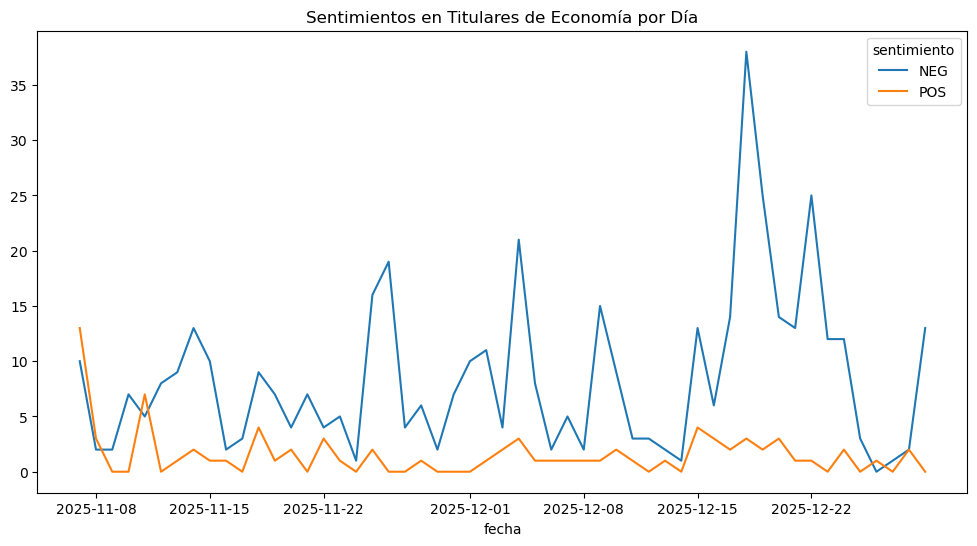

In [ ]:
# Crear gráfico en lienzo de 12x6
# Primero ver el conteo total de sentimientos
df_economia['sentimiento'].value_counts()

# Preparar los datos: conteo por fecha y sentimiento
# Filter rows where 'sentimiento' is not 'NEU'
filtered_df = df_economia[df_economia['sentimiento'] != 'NEU']

# Group by 'fecha' and count occurrences of each sentiment
sent_por_dia = filtered_df.groupby('fecha')['sentimiento'].value_counts().unstack().fillna(0)

# Gráfico de líneas con tamaño 12x6
sent_por_dia.plot(
    kind='line',
    title='Sentimientos en Titulares de Economía por Día',
    figsize=(12, 6)  # 👈 ¡Aquí se define el tamaño 12x6 (ancho x alto)!
)

### 📊 1. Political Entity Exposure Tracking
Measuring the cumulative media presence of key political figures over the evaluated quarter. This acts as a proxy for political capital or media scrutiny volume.

In [ ]:
# --- ANÁLISIS DE MENCIONES DIARIAS DE TÉRMINOS ESPECÍFICOS ---
# --- 1. CONFIGURACIÓN ---
# Define el rango de fechas que quieres analizar.
# pd.date_range se encarga de saber cuántos días tiene cada mes y los años bisiestos.
fecha_inicio = '2026-01-01'
fecha_fin = '2026-03-25'

terms = ["Revilla", "Dockweiler", "Jhonny Plata", "Yahuasi", "Iván Arias", "Reyes Villa", "Manuel Saavedra", "Leonardo Loza", "JP Velasco", "Otto Ritter", "Fernando Camacho"]

# Definimos qué términos deben ser insensibles a mayúsculas (case-insensitive)
# Es más limpio tenerlos en una lista o set aparte para modificarlo fácilmente.
terms_case_insensitive = {}#"dólares", "combustibles", "pan", "harina", "carne"}

lista_datos = []

# Generamos el rango de fechas automático
rango_fechas = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

print(f"Analizando menciones desde {fecha_inicio} hasta {fecha_fin}...")

# --- 2. PROCESAMIENTO ---
for fecha in rango_fechas:
    # Formato de fecha para el nombre del archivo y el reporte
    fecha_str = fecha.strftime('%Y-%m-%d')
    filename = f'noticias_{fecha_str}.csv'

    # Verificamos existencia antes de intentar leer
    if os.path.exists(filename):
        try:
            df_day = pd.read_csv(filename)

            # Limpieza preventiva: rellenar NaNs y asegurar string
            if 'cuerpo' in df_day.columns:
                df_day['cuerpo'] = df_day['cuerpo'].fillna('').astype(str)

                # Diccionario para almacenar los conteos de ESTE día
                conteo_dia = {'Fecha': fecha_str}

                for term in terms:
                    # Determinar si usamos IGNORECASE basándonos en la lista de configuración
                    flags = re.IGNORECASE if term in terms_case_insensitive else 0

                    # Contamos las ocurrencias (usando \b para palabra completa)
                    total_mentions = df_day['cuerpo'].str.count(
                        rf'\b{term}\b',
                        flags=flags
                    ).sum()

                    conteo_dia[term] = total_mentions

                lista_datos.append(conteo_dia)
            else:
                print(f"Advertencia: El archivo {filename} no tiene columna 'cuerpo'.")

        except Exception as e:
            print(f"Error procesando {filename}: {e}")

    # Si el archivo no existe, el loop simplemente continúa al siguiente día sin hacer nada (o puedes poner un print si deseas debug)

# --- 3. CREACIÓN DEL DATAFRAME FINAL ---
df_menciones = pd.DataFrame(lista_datos)

if not df_menciones.empty:
    # Rellenar con 0 si en algún caso extraño faltara un dato y asegurar orden de columnas
    df_menciones = df_menciones.fillna(0)

    # Ordenar columnas: Fecha primero, luego los términos
    cols = ['Fecha'] + [col for col in df_menciones.columns if col != 'Fecha']
    df_menciones = df_menciones[cols]

display(df_menciones)

Analizando menciones desde 2026-01-01 hasta 2026-03-25...


,Fecha,Revilla,Dockweiler,Jhonny Plata,Yahuasi,Iván Arias,Reyes Villa,Manuel Saavedra,Leonardo Loza,JP Velasco,Otto Ritter,Fernando Camacho
0,2026-01-01,1,0,0,0,4,0,0,2,0,0,1
1,2026-01-02,0,0,0,0,0,0,0,0,0,0,0
2,2026-01-03,0,0,0,0,2,0,0,0,0,0,6
3,2026-01-04,0,0,0,0,1,0,0,0,0,0,0
4,2026-01-05,0,0,0,0,6,0,0,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
79,2026-03-21,2,0,0,0,0,0,0,1,0,0,1
80,2026-03-22,23,18,5,2,11,23,10,10,10,15,12
81,2026-03-23,31,74,1,16,21,9,7,23,8,41,19
82,2026-03-24,1,27,0,0,6,2,6,5,9,12,6


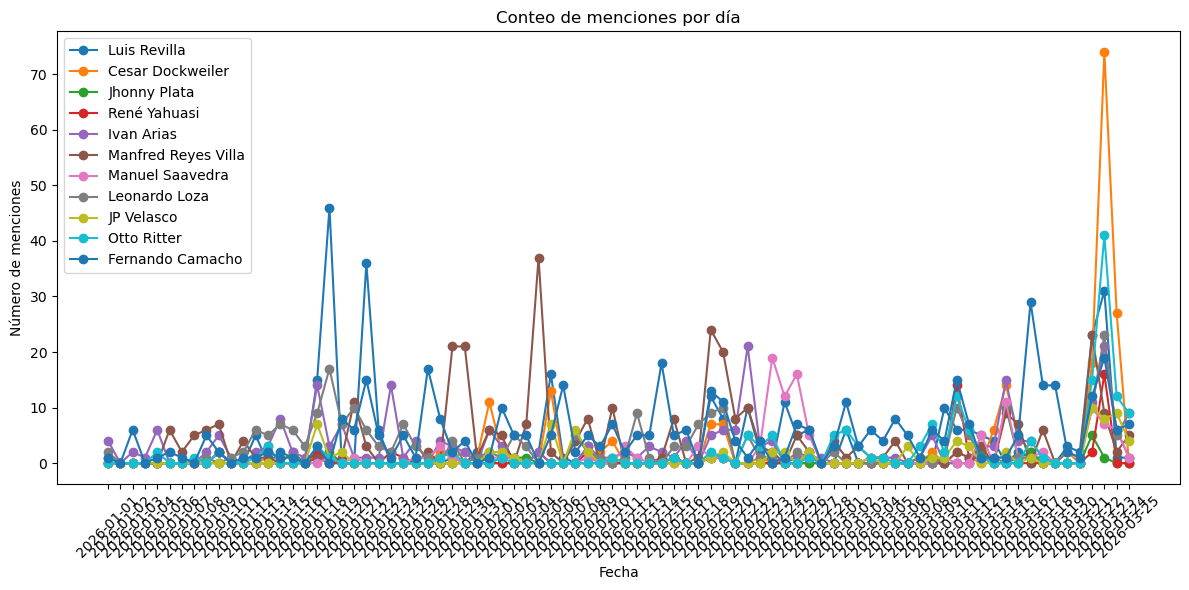

In [ ]:
# Graficar trayectoria de menciones por día
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df_menciones['Fecha'], df_menciones["Revilla"], marker='o', label='Luis Revilla')
plt.plot(df_menciones['Fecha'], df_menciones["Dockweiler"], marker='o', label='Cesar Dockweiler')
plt.plot(df_menciones['Fecha'], df_menciones["Jhonny Plata"], marker='o', label='Jhonny Plata')
plt.plot(df_menciones['Fecha'], df_menciones["Yahuasi"], marker='o', label='René Yahuasi')
plt.plot(df_menciones['Fecha'], df_menciones["Iván Arias"], marker='o', label='Ivan Arias')
plt.plot(df_menciones['Fecha'], df_menciones["Reyes Villa"], marker='o', label='Manfred Reyes Villa')
plt.plot(df_menciones['Fecha'], df_menciones["Manuel Saavedra"], marker='o', label='Manuel Saavedra')
plt.plot(df_menciones['Fecha'], df_menciones["Leonardo Loza"], marker='o', label='Leonardo Loza')
plt.plot(df_menciones['Fecha'], df_menciones["JP Velasco"], marker='o', label='JP Velasco')
plt.plot(df_menciones['Fecha'], df_menciones["Otto Ritter"], marker='o', label='Otto Ritter')
plt.plot(df_menciones['Fecha'], df_menciones["Fernando Camacho"], marker='o', label='Fernando Camacho')
plt.xlabel('Fecha')
plt.ylabel('Número de menciones')
plt.title('Conteo de menciones por día')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Crear un dataframe acumulado a partir de df_menciones
df_acumulado = df_menciones.copy()

# Aplicar cumsum() a todas las columnas excepto 'Fecha'
for col in df_acumulado.columns:
    if col != 'Fecha':
        df_acumulado[col] = df_acumulado[col].cumsum()

display(df_acumulado)

,Fecha,Revilla,Dockweiler,Jhonny Plata,Yahuasi,Iván Arias,Reyes Villa,Manuel Saavedra,Leonardo Loza,JP Velasco,Otto Ritter,Fernando Camacho
0,2026-01-01,1,0,0,0,4,0,0,2,0,0,1
1,2026-01-02,1,0,0,0,4,0,0,2,0,0,1
2,2026-01-03,1,0,0,0,6,0,0,2,0,0,7
3,2026-01-04,1,0,0,0,7,0,0,2,0,0,7
4,2026-01-05,1,0,0,0,13,0,0,2,0,2,8
...,...,...,...,...,...,...,...,...,...,...,...,...
79,2026-03-21,240,92,28,32,209,298,100,201,56,88,385
80,2026-03-22,263,110,33,34,220,321,110,211,66,103,397
81,2026-03-23,294,184,34,50,241,330,117,234,74,144,416
82,2026-03-24,295,211,34,50,247,332,123,239,83,156,422


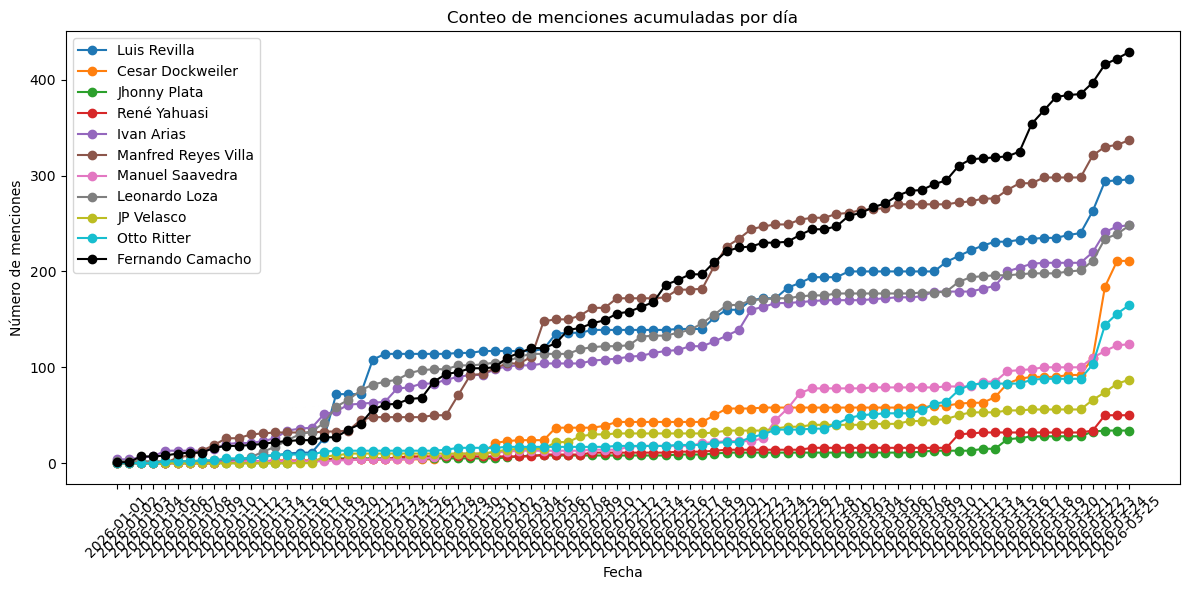

In [ ]:
# CONTEO ACUMULADO DE MENCIONES DIARIAS
# Graficar trayectoria de menciones acumuladas por día
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df_acumulado['Fecha'], df_acumulado["Revilla"], marker='o', label='Luis Revilla')
plt.plot(df_acumulado['Fecha'], df_acumulado["Dockweiler"], marker='o', label='Cesar Dockweiler')
plt.plot(df_acumulado['Fecha'], df_acumulado["Jhonny Plata"], marker='o', label='Jhonny Plata')
plt.plot(df_acumulado['Fecha'], df_acumulado["Yahuasi"], marker='o', label='René Yahuasi')
plt.plot(df_acumulado['Fecha'], df_acumulado["Iván Arias"], marker='o', label='Ivan Arias')
plt.plot(df_acumulado['Fecha'], df_acumulado["Reyes Villa"], marker='o', label='Manfred Reyes Villa')
plt.plot(df_acumulado['Fecha'], df_acumulado["Manuel Saavedra"], marker='o', label='Manuel Saavedra')
plt.plot(df_acumulado['Fecha'], df_acumulado["Leonardo Loza"], marker='o', label='Leonardo Loza')
plt.plot(df_acumulado['Fecha'], df_acumulado["JP Velasco"], marker='o', label='JP Velasco')
plt.plot(df_acumulado['Fecha'], df_acumulado["Otto Ritter"], marker='o', label='Otto Ritter')
plt.plot(df_acumulado['Fecha'], df_acumulado["Fernando Camacho"], marker='o', label='Fernando Camacho', color='black')
plt.xlabel('Fecha')
plt.ylabel('Número de menciones')
plt.title('Conteo de menciones acumuladas por día')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 🤖 2. Targeted Sentiment Analysis (RoBERTuito Pipeline)
Using Transformer-based Natural Language Processing to score headlines mentioning specific public officials. The model predicts probabilities for `NEG` (Negative) and `POS` (Positive) sentiment, allowing us to build an Economic/Political Confidence Index over time.

🔍 Procesando datos para: ['Carla Faval', 'vocera presidencial']
✅ Noticias encontradas: 157
🧠 Calculando negatividad (Pysentimiento)...


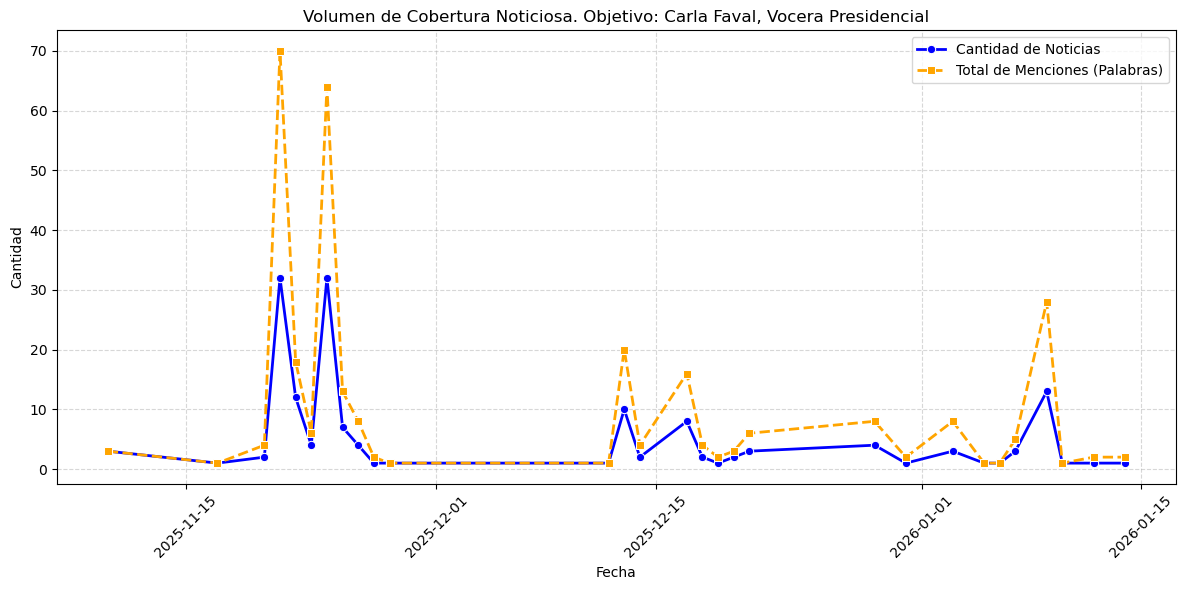

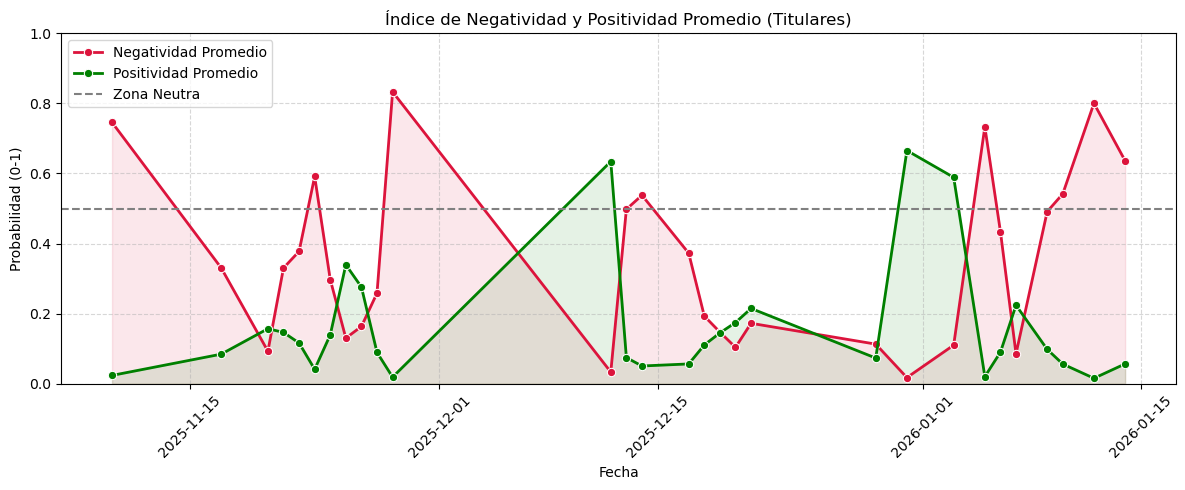

In [ ]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from pysentimiento import create_analyzer

# --- 1. CONFIGURACIÓN ---
fecha_inicio = '2024-11-07'
fecha_fin = '2026-01-14'

terminos_busqueda = ["Carla Faval", "vocera presidencial"]

# Regex optimizado: (?i) ignora mayúsculas, re.escape evita errores con caracteres especiales
patron_regex = r'(?i)' + '|'.join([re.escape(t) for t in terminos_busqueda])

dataframes_filtrados = []
rango_fechas = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

print(f"🔍 Procesando datos para: {terminos_busqueda}")

# --- 2. EXTRACCIÓN DE DATOS ---
for fecha in rango_fechas:
    fecha_str = fecha.strftime('%Y-%m-%d')
    filename = f'noticias_{fecha_str}.csv'

    if os.path.exists(filename):
        try:
            df_temp = pd.read_csv(filename)

            # Limpieza y validación de columnas
            if 'cuerpo' in df_temp.columns and 'titular' in df_temp.columns:
                df_temp['cuerpo'] = df_temp['cuerpo'].fillna('').astype(str)
                df_temp['titular'] = df_temp['titular'].fillna('').astype(str)

                # Contamos menciones en cada fila
                conteo_cuerpo = df_temp['cuerpo'].str.count(patron_regex)
                conteo_titular = df_temp['titular'].str.count(patron_regex)

                df_temp['menciones_totales'] = conteo_cuerpo + conteo_titular

                # Filtramos: Nos quedamos solo con las noticias que tienen al menos 1 mención
                df_matches = df_temp[df_temp['menciones_totales'] > 0].copy()

                if not df_matches.empty:
                    df_matches['fecha_archivo'] = fecha
                    dataframes_filtrados.append(df_matches)

        except Exception as e:
            print(f"Error en {filename}: {e}")

# Unificar
if dataframes_filtrados:
    df_interes = pd.concat(dataframes_filtrados, ignore_index=True)
    print(f"✅ Noticias encontradas: {len(df_interes)}")
else:
    print("❌ No se encontraron datos.")
    df_interes = pd.DataFrame()

# --- 3. ANÁLISIS DE SENTIMIENTOS ---

if not df_interes.empty:
    print("🧠 Calculando negatividad (Pysentimiento)...")

    analyzer = create_analyzer(task="sentiment", lang="es")

    def obtener_negatividad(texto):
        try:
            return analyzer.predict(texto).probas.get('NEG', 0.0)
        except:
            return 0.0

    # Aplicamos al titular
    df_interes['indice_negatividad'] = df_interes['titular'].apply(obtener_negatividad)

    # --- 4. AGRUPACIÓN POR DÍA ---
    df_interes['fecha_archivo'] = pd.to_datetime(df_interes['fecha_archivo'])

    resumen_diario = df_interes.groupby('fecha_archivo').agg(
        conteo_noticias=('titular', 'count'),       # Cuántas noticias distintas
        conteo_menciones=('menciones_totales', 'sum'), # Cuántas veces se dijo el nombre en total
        negatividad_promedio=('indice_negatividad', 'mean')
    ).reset_index()

    # --- 5. GRAFICACIÓN ---

    # GRÁFICO 1: COMPARATIVA NOTICIAS VS MENCIONES
    plt.figure(figsize=(12, 6))

    # Línea 1: Cantidad de Noticias (Azul)
    sns.lineplot(data=resumen_diario, x='fecha_archivo', y='conteo_noticias',
                 label='Cantidad de Noticias', color='blue', marker='o', linewidth=2)

    # Línea 2: Total de Menciones (Naranja)
    sns.lineplot(data=resumen_diario, x='fecha_archivo', y='conteo_menciones',
                 label='Total de Menciones (Palabras)', color='orange', marker='s', linestyle='--', linewidth=2)

    plt.title(f'Volumen de Cobertura Noticiosa. Objetivo: Carla Faval, Vocera Presidencial')
    plt.ylabel('Cantidad')
    plt.xlabel('Fecha')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # GRÁFICO 2: ÍNDICE DE NEGATIVIDAD Y POSITIVIDAD
    # Calculamos el índice de positividad
    def obtener_positividad(texto):
        try:
            return analyzer.predict(texto).probas.get('POS', 0.0)
        except:
            return 0.0

    df_interes['indice_positividad'] = df_interes['titular'].apply(obtener_positividad)

    resumen_diario = df_interes.groupby('fecha_archivo').agg(
        conteo_noticias=('titular', 'count'),
        conteo_menciones=('menciones_totales', 'sum'),
        negatividad_promedio=('indice_negatividad', 'mean'),
        positividad_promedio=('indice_positividad', 'mean')
    ).reset_index()

    plt.figure(figsize=(12, 5))
    # Línea de negatividad
    sns.lineplot(data=resumen_diario, x='fecha_archivo', y='negatividad_promedio',
                color='crimson', marker='o', linewidth=2, label='Negatividad Promedio')
    plt.fill_between(resumen_diario['fecha_archivo'], resumen_diario['negatividad_promedio'], color='crimson', alpha=0.1)

    # Línea de positividad
    sns.lineplot(data=resumen_diario, x='fecha_archivo', y='positividad_promedio',
                color='green', marker='o', linewidth=2, label='Positividad Promedio')
    plt.fill_between(resumen_diario['fecha_archivo'], resumen_diario['positividad_promedio'], color='green', alpha=0.1)

    plt.title('Índice de Negatividad y Positividad Promedio (Titulares)')
    plt.ylabel('Probabilidad (0-1)')
    plt.xlabel('Fecha')
    plt.ylim(0, 1)
    plt.axhline(0.5, color='gray', linestyle='--', label='Zona Neutra')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


🔍 Procesando datos para: ['Mauricio Medinaceli', 'Ministro de Hidrocarburos', 'Ministro Medinaceli']
✅ Noticias encontradas: 248
🧠 Calculando negatividad (Pysentimiento)...


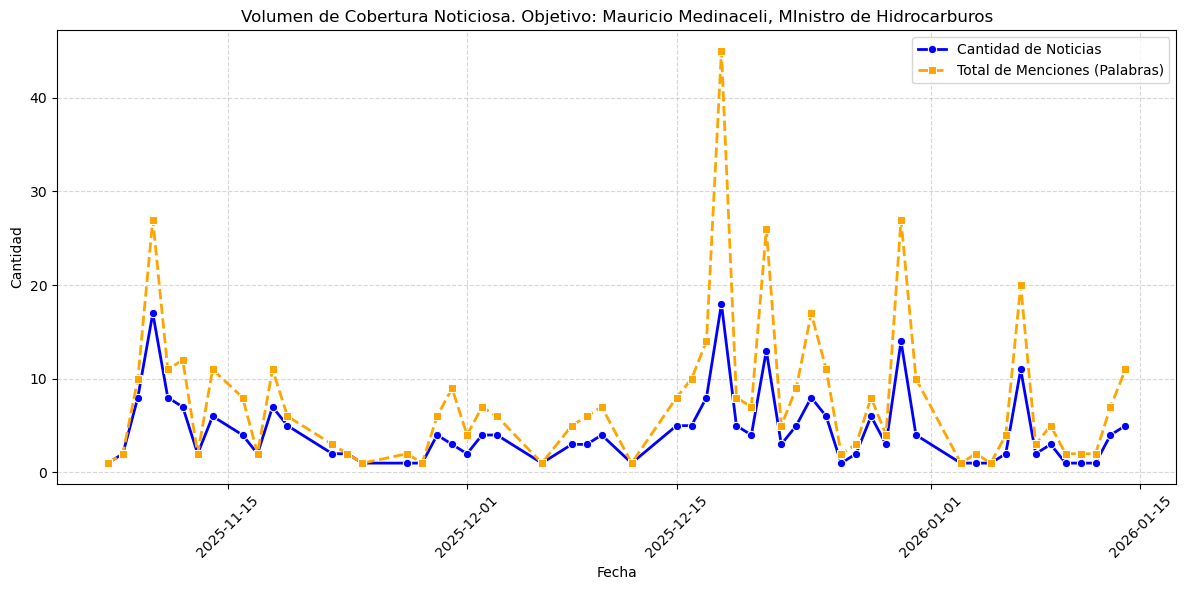

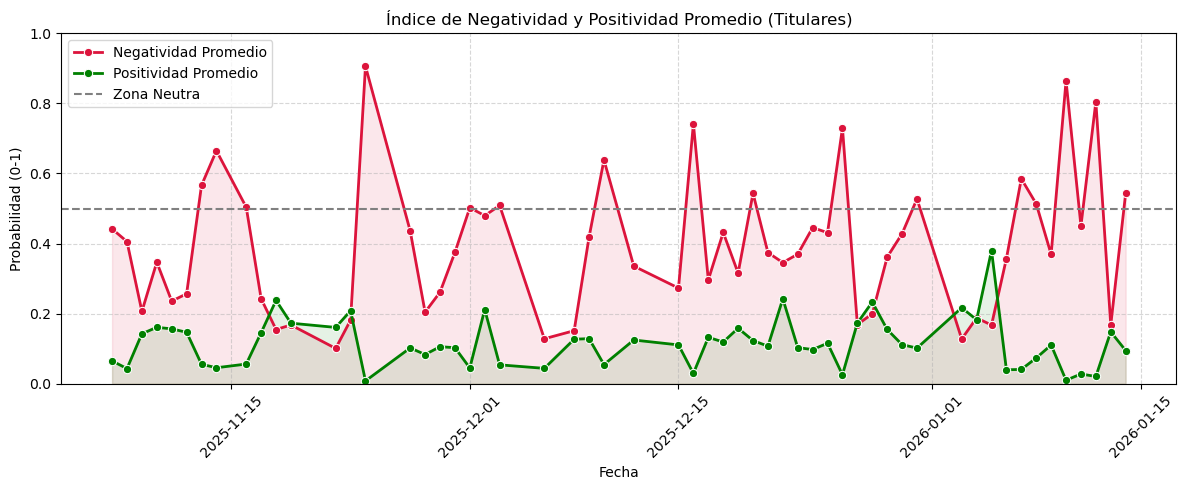

In [ ]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from pysentimiento import create_analyzer

# --- 1. CONFIGURACIÓN ---
fecha_inicio = '2024-11-07'
fecha_fin = '2026-01-14'

terminos_busqueda = ["Mauricio Medinaceli", "Ministro de Hidrocarburos", "Ministro Medinaceli"]

# Regex optimizado: (?i) ignora mayúsculas, re.escape evita errores con caracteres especiales
patron_regex = r'(?i)' + '|'.join([re.escape(t) for t in terminos_busqueda])

dataframes_filtrados = []
rango_fechas = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

print(f"🔍 Procesando datos para: {terminos_busqueda}")

# --- 2. EXTRACCIÓN DE DATOS ---
for fecha in rango_fechas:
    fecha_str = fecha.strftime('%Y-%m-%d')
    filename = f'noticias_{fecha_str}.csv'

    if os.path.exists(filename):
        try:
            df_temp = pd.read_csv(filename)

            # Limpieza y validación de columnas
            if 'cuerpo' in df_temp.columns and 'titular' in df_temp.columns:
                df_temp['cuerpo'] = df_temp['cuerpo'].fillna('').astype(str)
                df_temp['titular'] = df_temp['titular'].fillna('').astype(str)

                # Contamos menciones en cada fila
                conteo_cuerpo = df_temp['cuerpo'].str.count(patron_regex)
                conteo_titular = df_temp['titular'].str.count(patron_regex)

                df_temp['menciones_totales'] = conteo_cuerpo + conteo_titular

                # Filtramos: Nos quedamos solo con las noticias que tienen al menos 1 mención
                df_matches = df_temp[df_temp['menciones_totales'] > 0].copy()

                if not df_matches.empty:
                    df_matches['fecha_archivo'] = fecha
                    dataframes_filtrados.append(df_matches)

        except Exception as e:
            print(f"Error en {filename}: {e}")

# Unificar
if dataframes_filtrados:
    df_interes = pd.concat(dataframes_filtrados, ignore_index=True)
    print(f"✅ Noticias encontradas: {len(df_interes)}")
else:
    print("❌ No se encontraron datos.")
    df_interes = pd.DataFrame()

# --- 3. ANÁLISIS DE SENTIMIENTOS ---

if not df_interes.empty:
    print("🧠 Calculando negatividad (Pysentimiento)...")

    analyzer = create_analyzer(task="sentiment", lang="es")

    def obtener_negatividad(texto):
        try:
            return analyzer.predict(texto).probas.get('NEG', 0.0)
        except:
            return 0.0

    # Aplicamos al titular
    df_interes['indice_negatividad'] = df_interes['titular'].apply(obtener_negatividad)

    # --- 4. AGRUPACIÓN POR DÍA ---
    df_interes['fecha_archivo'] = pd.to_datetime(df_interes['fecha_archivo'])

    resumen_diario = df_interes.groupby('fecha_archivo').agg(
        conteo_noticias=('titular', 'count'),       # Cuántas noticias distintas
        conteo_menciones=('menciones_totales', 'sum'), # Cuántas veces se dijo el nombre en total
        negatividad_promedio=('indice_negatividad', 'mean')
    ).reset_index()

    # --- 5. GRAFICACIÓN ---

    # GRÁFICO 1: COMPARATIVA NOTICIAS VS MENCIONES
    plt.figure(figsize=(12, 6))

    # Línea 1: Cantidad de Noticias (Azul)
    sns.lineplot(data=resumen_diario, x='fecha_archivo', y='conteo_noticias',
                 label='Cantidad de Noticias', color='blue', marker='o', linewidth=2)

    # Línea 2: Total de Menciones (Naranja)
    sns.lineplot(data=resumen_diario, x='fecha_archivo', y='conteo_menciones',
                 label='Total de Menciones (Palabras)', color='orange', marker='s', linestyle='--', linewidth=2)

    plt.title(f'Volumen de Cobertura Noticiosa. Objetivo: Mauricio Medinaceli, MInistro de Hidrocarburos')
    plt.ylabel('Cantidad')
    plt.xlabel('Fecha')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # GRÁFICO 2: ÍNDICE DE NEGATIVIDAD Y POSITIVIDAD
    # Calculamos el índice de positividad
    def obtener_positividad(texto):
        try:
            return analyzer.predict(texto).probas.get('POS', 0.0)
        except:
            return 0.0

    df_interes['indice_positividad'] = df_interes['titular'].apply(obtener_positividad)

    resumen_diario = df_interes.groupby('fecha_archivo').agg(
        conteo_noticias=('titular', 'count'),
        conteo_menciones=('menciones_totales', 'sum'),
        negatividad_promedio=('indice_negatividad', 'mean'),
        positividad_promedio=('indice_positividad', 'mean')
    ).reset_index()

    plt.figure(figsize=(12, 5))
    # Línea de negatividad
    sns.lineplot(data=resumen_diario, x='fecha_archivo', y='negatividad_promedio',
                color='crimson', marker='o', linewidth=2, label='Negatividad Promedio')
    plt.fill_between(resumen_diario['fecha_archivo'], resumen_diario['negatividad_promedio'], color='crimson', alpha=0.1)

    # Línea de positividad
    sns.lineplot(data=resumen_diario, x='fecha_archivo', y='positividad_promedio',
                color='green', marker='o', linewidth=2, label='Positividad Promedio')
    plt.fill_between(resumen_diario['fecha_archivo'], resumen_diario['positividad_promedio'], color='green', alpha=0.1)

    plt.title('Índice de Negatividad y Positividad Promedio (Titulares)')
    plt.ylabel('Probabilidad (0-1)')
    plt.xlabel('Fecha')
    plt.ylim(0, 1)
    plt.axhline(0.5, color='gray', linestyle='--', label='Zona Neutra')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
#!pip install pysentimiento

In [ ]:
# Iniciar análisis de sentimientos con RoBERTuitoan-base-BNE
from transformers import pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model="pysentimiento/robertuito-sentiment-analysis")
# Analizar sentimientos en la columna 'titular'
df_noticias['sentimiento_titular'] = df_noticias['titular'].apply(lambda x: sentiment_analyzer(x)[0]['label'])
display(df_noticias[['fecha', 'titular', 'sentimiento_titular', 'sitio_noticias', 'seccion']])

,fecha,titular,sentimiento_titular,sitio_noticias,seccion
0,2025-11-07,CNI alerta: Ley de diferimiento ‘atenta contra...,NEG,La Razón,Economia
1,2025-11-07,Exministro Parada busca ser remitido a juicio ...,NEU,La Razón,Economia
2,2025-11-07,"PGE 2026 prevé crecimiento de solo 0,9% y défi...",NEU,La Razón,Economia
3,2025-11-07,Asosur dice que surtidores están listos y agua...,NEU,La Razón,Economia
4,2025-11-07,Banco Mundial y FLAR destacan avance de pagos ...,NEU,La Razón,Economia
...,...,...,...,...,...
11067,2025-12-13,Policía despliega refuerzos por crecida del rí...,NEU,Radio FM Bolivia,Nacional
11068,2025-12-13,Prada revela que Arce padece cáncer con metást...,NEG,Radio FM Bolivia,Nacional
11069,2025-12-13,MAS pide la “pena más dura” para Luis Arce si ...,NEG,Radio FM Bolivia,Politica
11070,2025-12-13,Hallan un hombre sin vida tras crecida de un r...,NEG,Radio FM Bolivia,Nacional


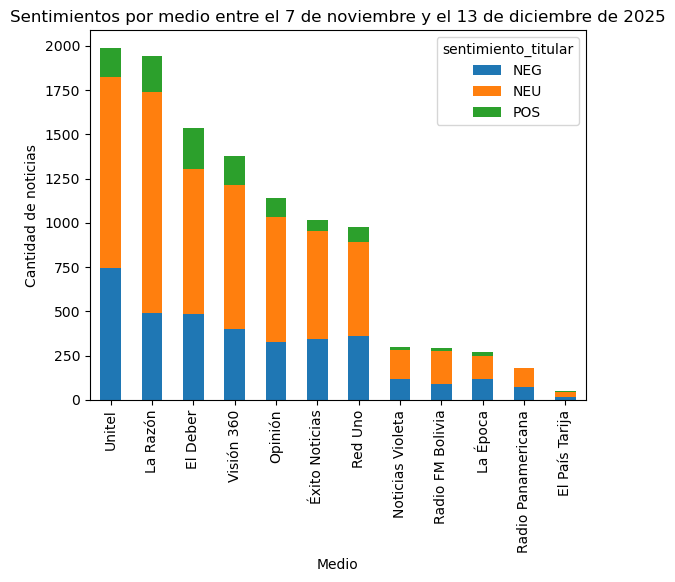

In [ ]:
# Gráfico de sentimientos por medio (en porcentaje)
sentiment_by_site = df_noticias.pivot_table(index='sitio_noticias', columns='sentimiento_titular', aggfunc='size', fill_value=0)
# Ordenamos de mayor a menor por el total de noticias
sentiment_by_site['Total'] = sentiment_by_site.sum(axis=1)
sentiment_by_site = sentiment_by_site.sort_values(by='Total', ascending=False)
# sentiment_by_site_percent = sentiment_by_site.div(sentiment_by_site.sum(axis=1), axis=0) * 100
# Omitir 'total'
sentiment_by_site.drop(columns=['Total'], inplace=True)
sentiment_by_site.plot(kind='bar', stacked=True)
plt.title('Sentimientos por medio entre el 7 de noviembre y el 13 de diciembre de 2025')
plt.xlabel('Medio')
plt.ylabel('Cantidad de noticias')
plt.show()

In [ ]:
df_noticias['sitio_noticias'].value_counts()

sitio_noticias
Unitel                1988
La Razón              1944
El Deber              1535
Visión 360            1380
Opinión               1140
Éxito Noticias        1018
Red Uno                978
Noticias Violeta       301
Radio FM Bolivia       292
La Época               268
Radio Panamericana     180
El País Tarija          48
Name: count, dtype: int64

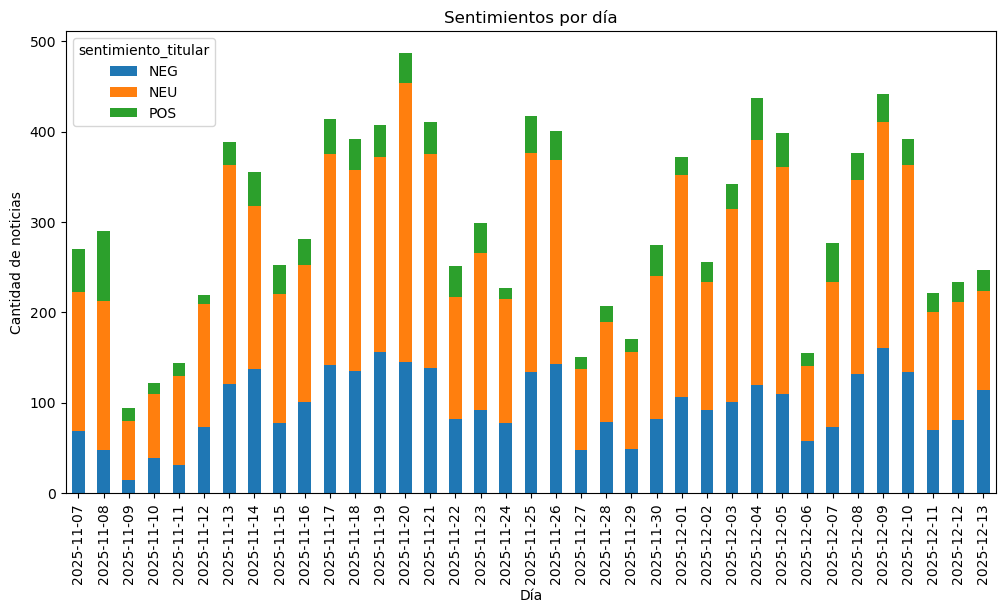

In [ ]:
# Gráfico de sentimientos por día
import matplotlib.pyplot as plt

sentiment_by_day = df_noticias.groupby(['fecha', 'sentimiento_titular']).size().unstack(fill_value=0)
sentiment_by_day.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Sentimientos por día')
plt.xlabel('Día')
plt.ylabel('Cantidad de noticias')
plt.show()